In [3]:
import os

# ===== مسارات الصور والـ labels =====
images_dir = r"D:\projects\facec detection\Face_detection\images\train"
labels_dir = r"D:\projects\facec detection\Face_detection\labels\train"

# ===== جلب كل الملفات =====
images = [f for f in os.listdir(images_dir) if f.endswith((".jpg", ".png"))]
labels = [f for f in os.listdir(labels_dir) if f.endswith(".txt")]

# ===== عرض معلومات =====
print(f"عدد الصور في train: {len(images)}")
print(f"عدد ملفات labels في train: {len(labels)}")

# ===== عرض أول 5 ملفات =====
print("\nأول 5 صور:")
print(images[:5])

print("\nأول 5 labels:")
print(labels[:5])

# ===== التأكد من مطابقة الصور والـ labels =====
matching = all(os.path.splitext(img)[0] + ".txt" in labels for img in images)
if matching:
    print("\n✅ كل الصور لها ملف label مطابق.")
else:
    print("\n❌ في صور ناقصة labels.")


عدد الصور في train: 13386
عدد ملفات labels في train: 13386

أول 5 صور:
['00006c07d2b033d1.jpg', '0000bee39176697a.jpg', '0000eda1171fe14e.jpg', '00090bdd55ec42c3.jpg', '000d1eae99343db8.jpg']

أول 5 labels:
['00006c07d2b033d1.txt', '0000bee39176697a.txt', '0000eda1171fe14e.txt', '00090bdd55ec42c3.txt', '000d1eae99343db8.txt']

✅ كل الصور لها ملف label مطابق.


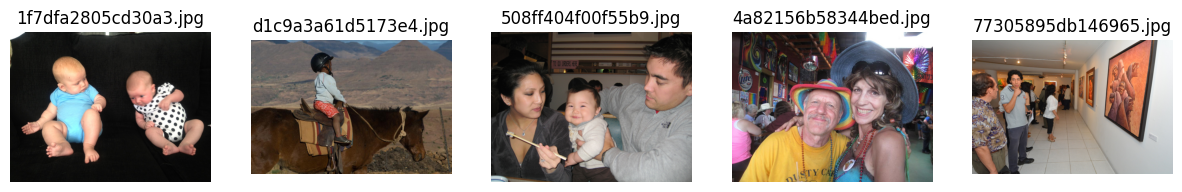

In [4]:
import os
import cv2
import random
from matplotlib import pyplot as plt

# ===== مسار فولدر train =====
train_images_dir = r"D:\projects\facec detection\Face_detection\images\train"

# ===== جلب كل الصور =====
images = [f for f in os.listdir(train_images_dir) if f.endswith((".jpg", ".png"))]

# ===== عرض 5 صور عشوائية =====
sample_images = random.sample(images, 5)

plt.figure(figsize=(15,5))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(train_images_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # تحويل BGR -> RGB

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()


In [7]:
from ultralytics import YOLO
model=YOLO("yolov8n.pt")

res=model.train(
    data="data.yaml",
    epochs=3,
    project='Face detection',
    imgsz=640,
    batch=32,
    # data augmentation
    fliplr=0.5,           # 50% flip أفقياً
    flipud=0.0,           # 0% flip عمودي
    hsv_h=0.015,          # Hue
    hsv_s=0.7,            # Saturation
    hsv_v=0.4,            # Brightness
    degrees=10,           # تدوير ±10
    translate=0.1,        # نقل ±10%
    scale=0.5,            # تكبير/تصغير ±50%
    shear=2               # shear ±2
    )


New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.252  Python-3.13.5 torch-2.9.1+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, op

In [8]:
model=YOLO("Face detection/train/weights/best.pt")
metrics=model.val(data="data.yaml")
print(metrics)

Ultralytics 8.3.252  Python-3.13.5 torch-2.9.1+cpu CPU (12th Gen Intel Core i7-12700H)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 331.8210.2 MB/s, size: 186.2 KB)
val: Scanning D:\projects\facec detection\Face_detection\labels\val.cache... 3347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3347/3347 877.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 210/210 1.3it/s 2:45<0.6s
                   all       3347      10299      0.882      0.744      0.824      0.515
Speed: 0.5ms preprocess, 39.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\projects\facec detection\Face_detection\runs\detect\val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000

In [10]:
test_image=r"C:\Image and Movie\1712735139764.jpg"
result=model.predict(
    source=test_image,
    conf=.4,
    save=True
)
print("presection done ")


image 1/1 C:\Image and Movie\1712735139764.jpg: 480x640 4 Faces, 55.3ms
Speed: 3.9ms preprocess, 55.3ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to D:\projects\facec detection\Face_detection\runs\detect\predict
presection done 


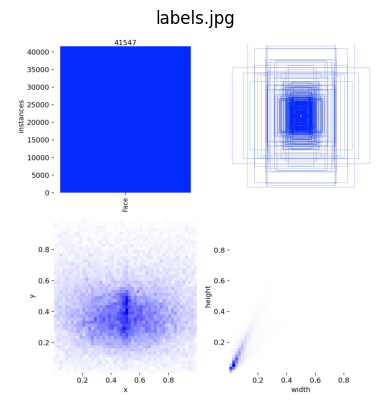

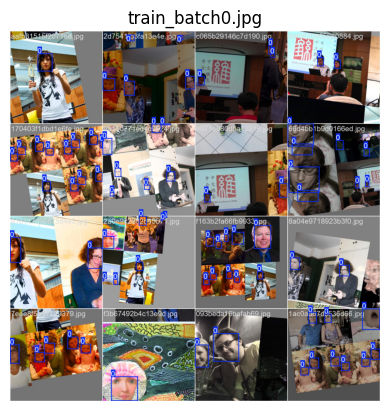

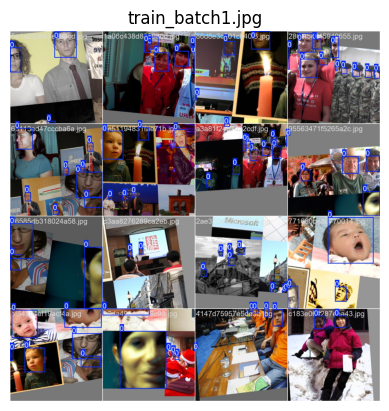

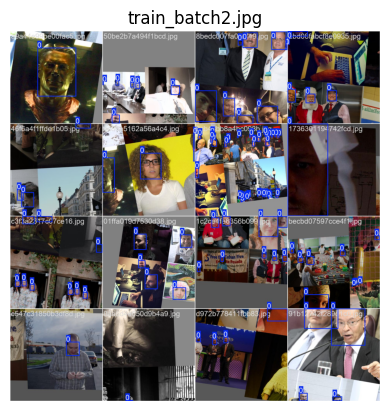

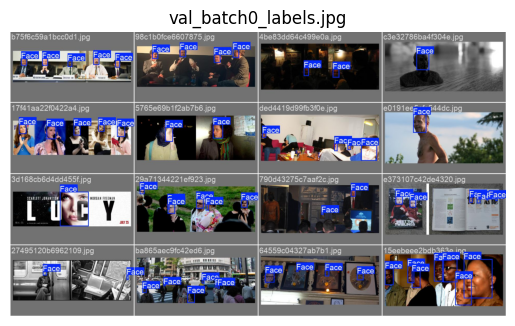

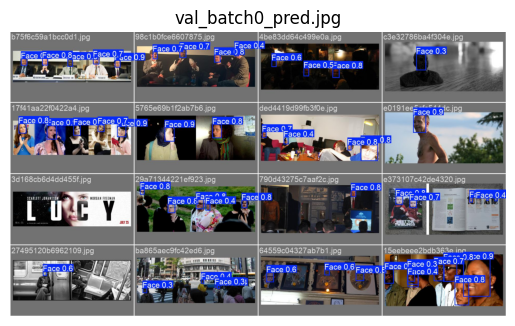

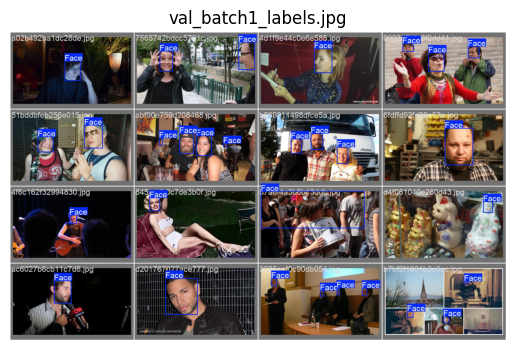

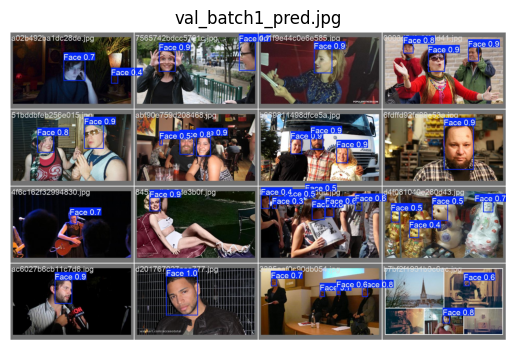

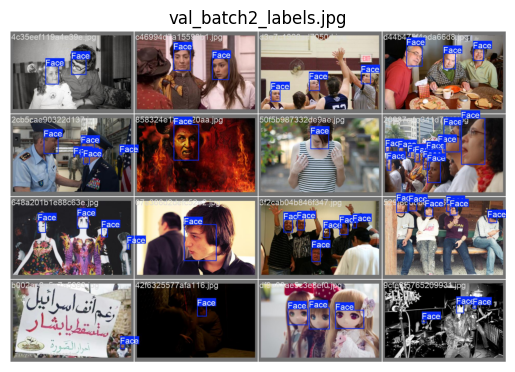

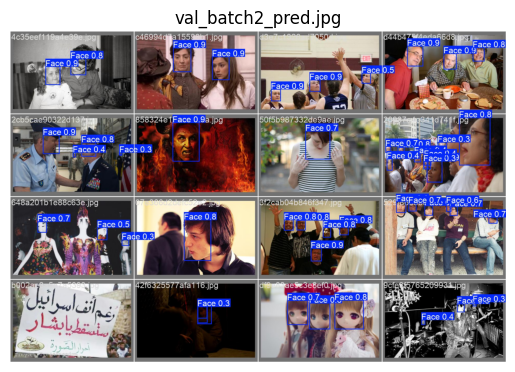

In [23]:
import os
import cv2
from matplotlib import pyplot as plt
import glob

# ===== مسار فولدر نتائج YOLO =====
results_dir = r"D:\projects\facec detection\Face_detection\Face detection\train"

# ===== جلب كل الصور في الفولدر recursively =====
all_images = glob.glob(os.path.join(results_dir, "**/*.jpg"), recursive=True)

for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()


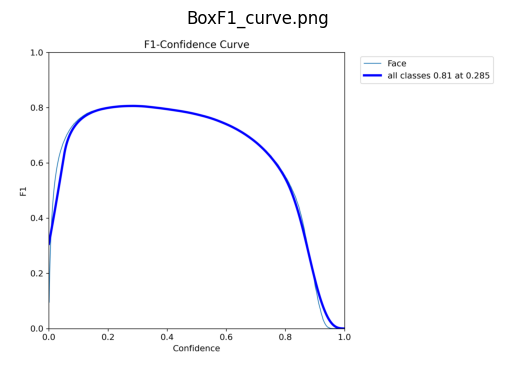

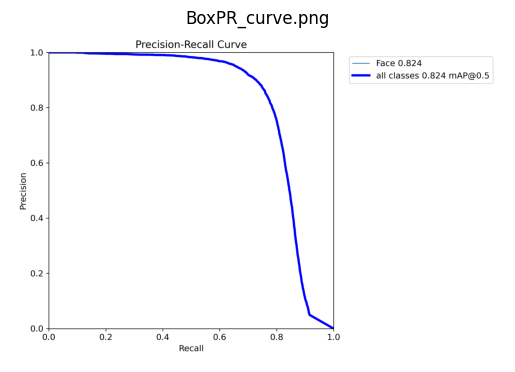

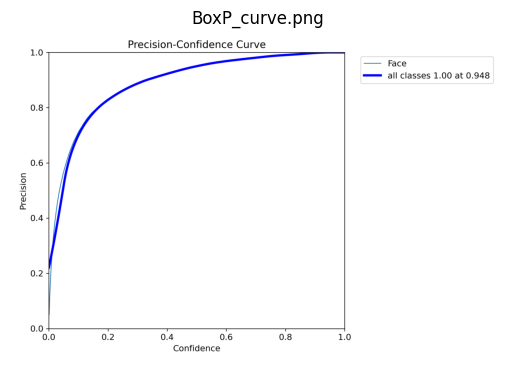

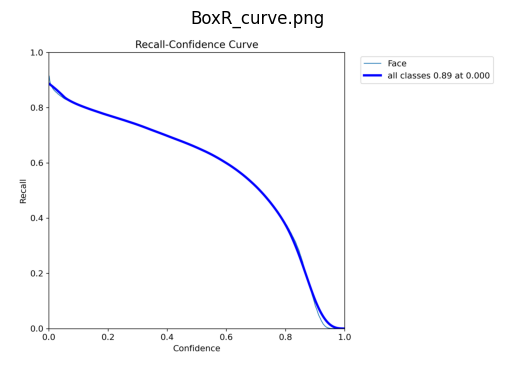

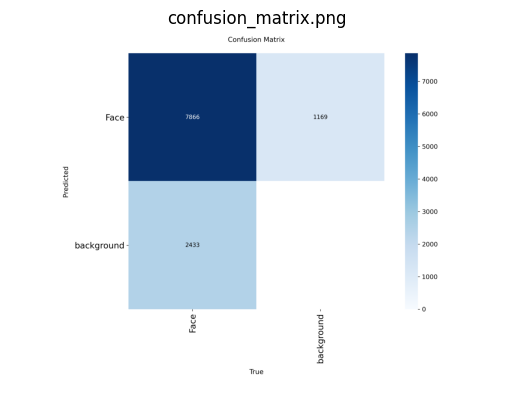

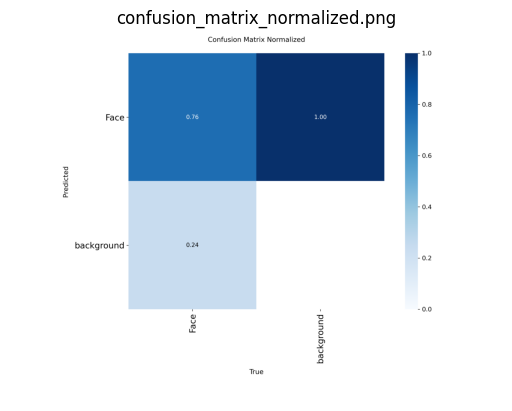

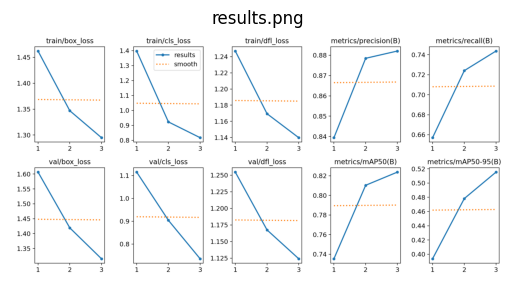

In [24]:
import os
import cv2
from matplotlib import pyplot as plt
import glob

# ===== مسار فولدر نتائج YOLO =====
results_dir = r"D:\projects\facec detection\Face_detection\Face detection\train"

# ===== جلب كل الصور في الفولدر recursively =====
all_images = glob.glob(os.path.join(results_dir, "**/*.png"), recursive=True)

for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()


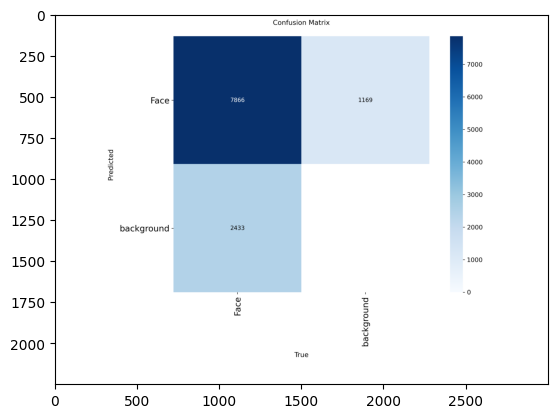

In [18]:
confusion_metric=r"Face detection/train/confusion_matrix.png"
img=cv2.imread(confusion_metric)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
plt.imshow(img)